# 미니프로젝트: 앙상블 모델링 (Vibe Coding)

#### <목표>
Day 3에서 배운 **Random Forest, GBM, XGBoost, LightGBM, CatBoost**를 Day 2와 **동일한 제조 데이터셋**에 적용해 봅니다.

- Day 1에서의 EDA, 전처리를 복습해보고
- Day 2에서 배웠던 다중선형회귀·Ridge·Lasso·의사결정나무로 만든 결과와 비교하면서
- Day 3에서 배운 앙상블 모델이 단일 모델 대비 어떤 성능 차이를 보이는지 확인해봅니다.

#### <데이터셋 소개>

**1) 회귀용 — Mining Process Flotation Plant (광물 선광 공정 데이터)**
- 철광석을 선광(flotation)하는 공정에서 1시간 간격으로 수집된 실제 산업 데이터
- 공정 변수로 최종 정광의 불순물(실리카) 비율을 예측

| 변수명 | 설명 |
|:---:|:---|
| date | 측정 일시 |
| % Iron Feed, % Silica Feed | 투입 원광의 철/실리카 품위 |
| Starch Flow, Amina Flow | 전분/아민 투입량 (시약) |
| Ore Pulp Flow, pH, Density | 광액 유량/산도/밀도 |
| Flotation Column 01~07 Air Flow | 플로테이션 컬럼별 공기 유량 |
| Flotation Column 01~07 Level | 플로테이션 컬럼별 액위 |
| % Iron Concentrate | 최종 정광의 철 비율 (실험실 측정) |
| **% Silica Concentrate** | **최종 정광의 실리카(불순물) 비율 — 회귀 타겟** |

**2) 분류용 — Steel Plates Faults (철강 표면 결함 검사 데이터)**
- 철강판 표면을 촬영해 측정한 결함의 위치/크기/광도 등으로 결함 유형을 분류하는 실제 품질검사 데이터

| 변수명 | 설명 |
|:---:|:---|
| X/Y_Minimum, X/Y_Maximum | 결함의 위치 범위 |
| Pixels_Areas, X/Y_Perimeter | 결함의 면적·둘레 |
| Sum/Minimum/Maximum_of_Luminosity | 결함 부위의 광도 |
| Length_of_Conveyer, Steel_Plate_Thickness | 설비/소재 정보 |
| TypeOfSteel_A300, TypeOfSteel_A400 | 철강 타입 |
| Edges_Index, Square_Index, Luminosity_Index 등 | 결함 형태 특징 지수 |
| Pastry, Z_Scratch, K_Scatch, Stains, Dirtiness, Bumps, Other_Faults | 결함 유형 |
| **K_Scatch** | **긴 스크래치성 결함 여부 — 분류 타겟** |

#### <실습 태스크>
| 태스크 | 데이터 파일 | 타겟 변수 | 사용 모델 |
|:---:|:---:|:---:|:---|
| 회귀 | `dataset/day2_miniproject_reg.csv` | `% Silica Concentrate` | Random Forest, GBM, XGBoost, LightGBM, CatBoost (회귀) |
| 분류 | `dataset/day2_miniproject_cls.csv` | `K_Scatch` | Random Forest, GBM, XGBoost, LightGBM, CatBoost (분류) |

#### <진행 순서>
**Part A(회귀)** 를 데이터 불러오기 → 탐색 → 전처리 → 모델링 → 예측 → 고도화 → 결과 해석까지 **끝까지 완료한 뒤**, **Part B(분류)** 를 동일한 흐름으로 진행합니다.

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

**[과제]** 써니는 Day 2에서 사용한 회귀 및 분류 데이터셋에 다양한 트리 기반 앙상블 모델을 적용해 보려고 합니다. 분석 준비와 데이터 전처리뿐만 아니라, 앙상블 모델 구축 및 하이퍼파라미터 탐색에 필요한 라이브러리를 AI와 상의하여 선정하고 불러오는 코드를 작성해 보세요.

In [1]:
# [과제] 앙상블 모델링 + Day 2 모델 비교용 라이브러리
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

# Day 2 모델 (비교용)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Day 3 앙상블 모델
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor, CatBoostClassifier

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix,
)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


---
# Part A. 회귀 태스크 — Mining Process Flotation Plant

## A-0) 데이터 불러오기

**[과제]** 써니는 Day 2에서 사용했던 `dataset/day2_miniproject_reg.csv` 파일을 그대로 불러오려고 합니다. 적절한 변수명으로 데이터프레임을 만들어 보세요.

In [2]:
# [과제] 회귀 데이터 불러오기
reg_df = pd.read_csv(os.path.join("dataset", "day2_miniproject_reg.csv"))

print("shape:", reg_df.shape)
display(reg_df.head())
reg_df.info()


shape: (3948, 24)


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,3/29/2017 12:00,60.18,9.34,1060.859297,379.836203,400.982539,9.527187,1.550374,200.035839,195.577700,...,249.992956,753.724247,726.559437,860.557818,477.349197,452.512522,478.219647,470.105547,66.44,1.36
1,3/29/2017 13:00,60.18,9.34,2034.926525,322.233975,400.468947,9.700679,1.532017,199.990122,195.106250,...,250.059711,848.675503,777.784437,869.419421,483.816131,469.448172,471.607075,462.665478,66.57,1.43
2,3/29/2017 14:00,60.18,9.34,1435.425811,474.656322,399.157083,9.687788,1.645200,200.019311,195.604928,...,250.111328,851.951492,776.293654,879.704989,456.147231,453.227000,447.708467,453.475667,66.64,1.33
3,3/29/2017 15:00,60.18,9.34,618.460387,396.377733,398.942522,9.851689,1.559929,199.940833,195.657094,...,250.028506,855.910630,780.369869,882.093896,449.410744,448.581506,450.697578,448.660094,66.41,1.27
4,3/29/2017 16:00,59.54,9.56,1367.502858,317.134072,400.836283,9.936163,1.530984,199.878922,196.162864,...,250.122067,851.603513,784.446084,884.840698,450.123050,451.774694,451.574422,449.406894,63.63,5.50


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3948 entries, 0 to 3947
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   date                          3948 non-null   object 
 1   % Iron Feed                   3948 non-null   float64
 2   % Silica Feed                 3948 non-null   float64
 3   Starch Flow                   3948 non-null   float64
 4   Amina Flow                    3948 non-null   float64
 5   Ore Pulp Flow                 3948 non-null   float64
 6   Ore Pulp pH                   3948 non-null   float64
 7   Ore Pulp Density              3948 non-null   float64
 8   Flotation Column 01 Air Flow  3948 non-null   float64
 9   Flotation Column 02 Air Flow  3948 non-null   float64
 10  Flotation Column 03 Air Flow  3948 non-null   float64
 11  Flotation Column 04 Air Flow  3948 non-null   float64
 12  Flotation Column 05 Air Flow  3948 non-null   float64
 13  Flo

---
## A-1) 데이터 탐색 (EDA)

### A-1-1) Value 기반 탐색

**[과제]** 써니는 오늘도 모델링에 앞서 데이터 상태를 다시 한번 점검하고 싶습니다. AI와 함께 데이터 구조, 결측치, 수집 기간 등 기본적인 특성을 다시 확인해 보세요.

In [3]:
# [과제] Value 기반 EDA: 구조, 결측치, 수집 기간 확인

# 1) 결측치 개수
print("[결측치 개수]")
print(reg_df.isna().sum())

# 2) 데이터 타입 / 구조
print("\n[데이터 타입]")
print(reg_df.dtypes)
print("\nshape:", reg_df.shape)
reg_df.info()

# 3) 중복 행
dup_cnt = reg_df.duplicated().sum()
print(f"\n[중복 행 개수] {dup_cnt}")

# 4) date 변환 후 수집 기간 확인
reg_df["date"] = pd.to_datetime(reg_df["date"])
reg_df = reg_df.sort_values("date").reset_index(drop=True)
print("\n[수집 기간]")
print("시작:", reg_df["date"].min())
print("종료:", reg_df["date"].max())
print("기간(일):", (reg_df["date"].max() - reg_df["date"].min()).days)


[결측치 개수]
date                            0
% Iron Feed                     0
% Silica Feed                   0
Starch Flow                     0
Amina Flow                      0
Ore Pulp Flow                   0
Ore Pulp pH                     0
Ore Pulp Density                0
Flotation Column 01 Air Flow    0
Flotation Column 02 Air Flow    0
Flotation Column 03 Air Flow    0
Flotation Column 04 Air Flow    0
Flotation Column 05 Air Flow    0
Flotation Column 06 Air Flow    0
Flotation Column 07 Air Flow    0
Flotation Column 01 Level       0
Flotation Column 02 Level       0
Flotation Column 03 Level       0
Flotation Column 04 Level       0
Flotation Column 05 Level       0
Flotation Column 06 Level       0
Flotation Column 07 Level       0
% Iron Concentrate              0
% Silica Concentrate            0
dtype: int64

[데이터 타입]
date                             object
% Iron Feed                     float64
% Silica Feed                   float64
Starch Flow                     

### A-1-2) Graph 기반 탐색

**[과제]** 써니는 오늘도 어제처럼 시계열 변화 패턴과 변수 간 상관관계를 앙상블 모델링 전에 다시 시각화로 점검하려고 합니다. AI와 함께 시간 흐름에 따른 변수 변화를 시각화해 보세요.

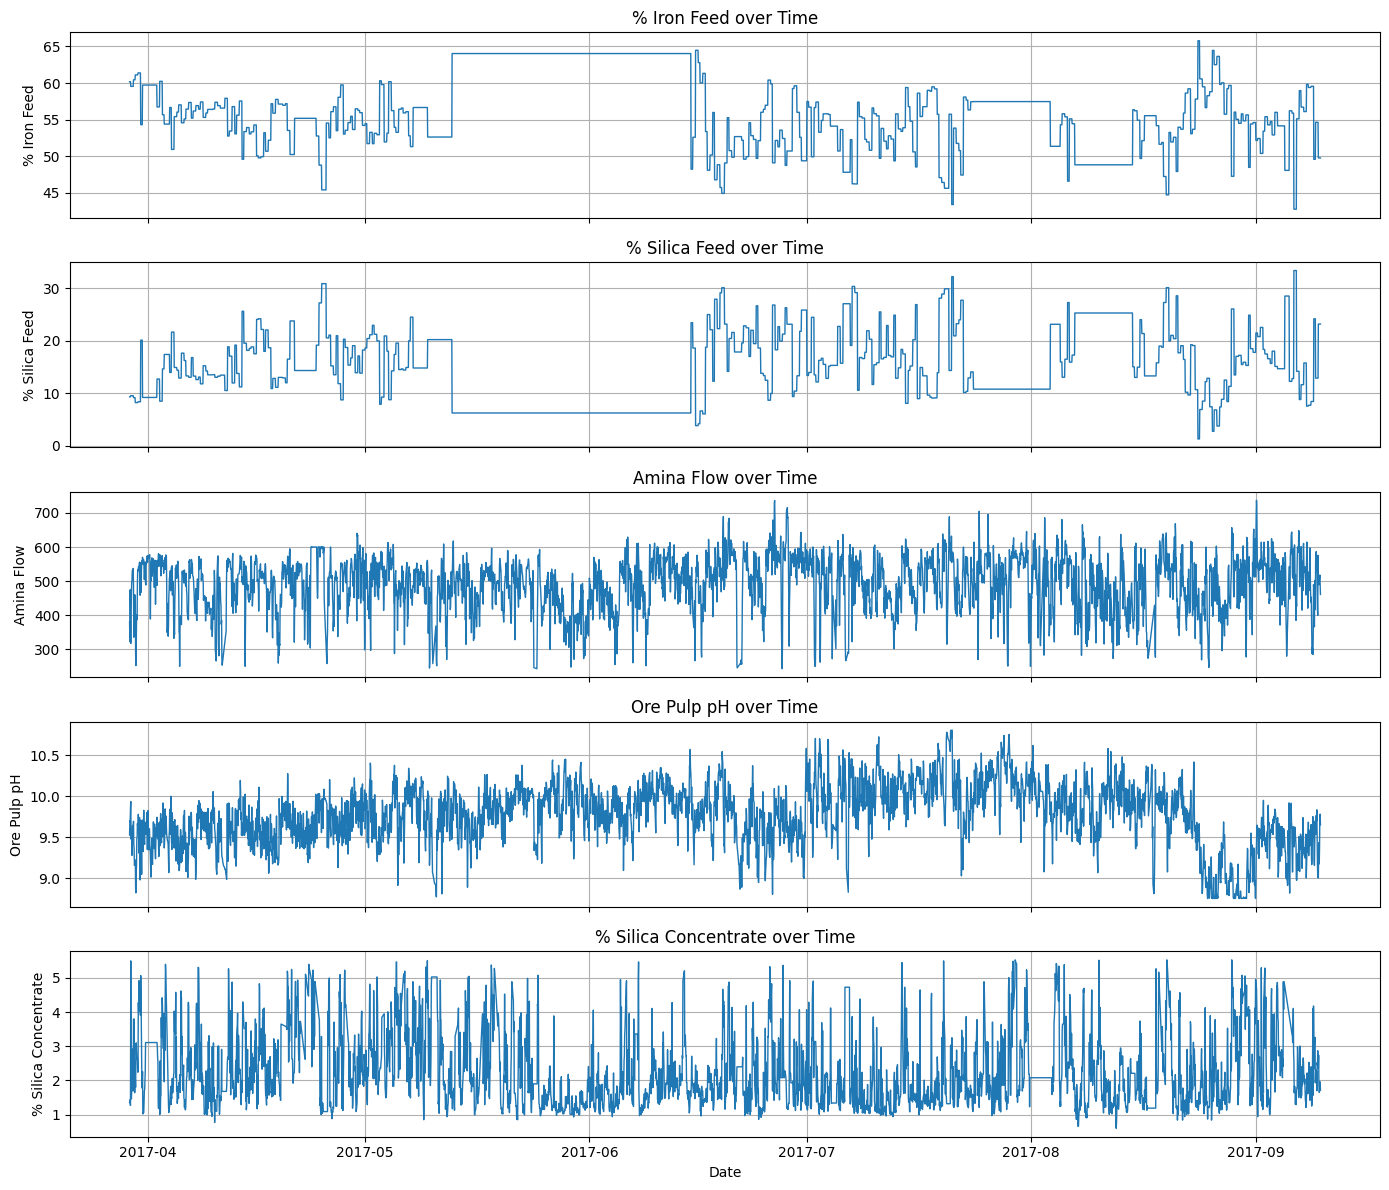

In [4]:
# [과제] 시계열 변수 변화 시각화 (line plot)
# A-1-1에서 date 변환·시간순 정렬 완료 (정렬하지 않으면 그래프가 지그재그로 왜곡됨)

time_cols = [
    "% Iron Feed",
    "% Silica Feed",
    "Amina Flow",
    "Ore Pulp pH",
    "% Silica Concentrate",
]

fig, axes = plt.subplots(len(time_cols), 1, figsize=(14, 12), sharex=True)

for i, col in enumerate(time_cols):
    axes[i].plot(reg_df["date"], reg_df[col], linewidth=1)
    axes[i].set_title(f"{col} over Time")
    axes[i].set_ylabel(col)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


**[과제]** 써니는 변수들 간에 강하게 얽혀 있는 관계(다중공선성 후보)가 있는지 한눈에 살펴보고 싶습니다. AI와 상의해서 상관관계 히트맵을 그려보고 트리 기반 앙상블 모델에서는 이 다중공선성이 Day 2의 선형 모델만큼 문제가 되는지도 함께 생각해 보세요.

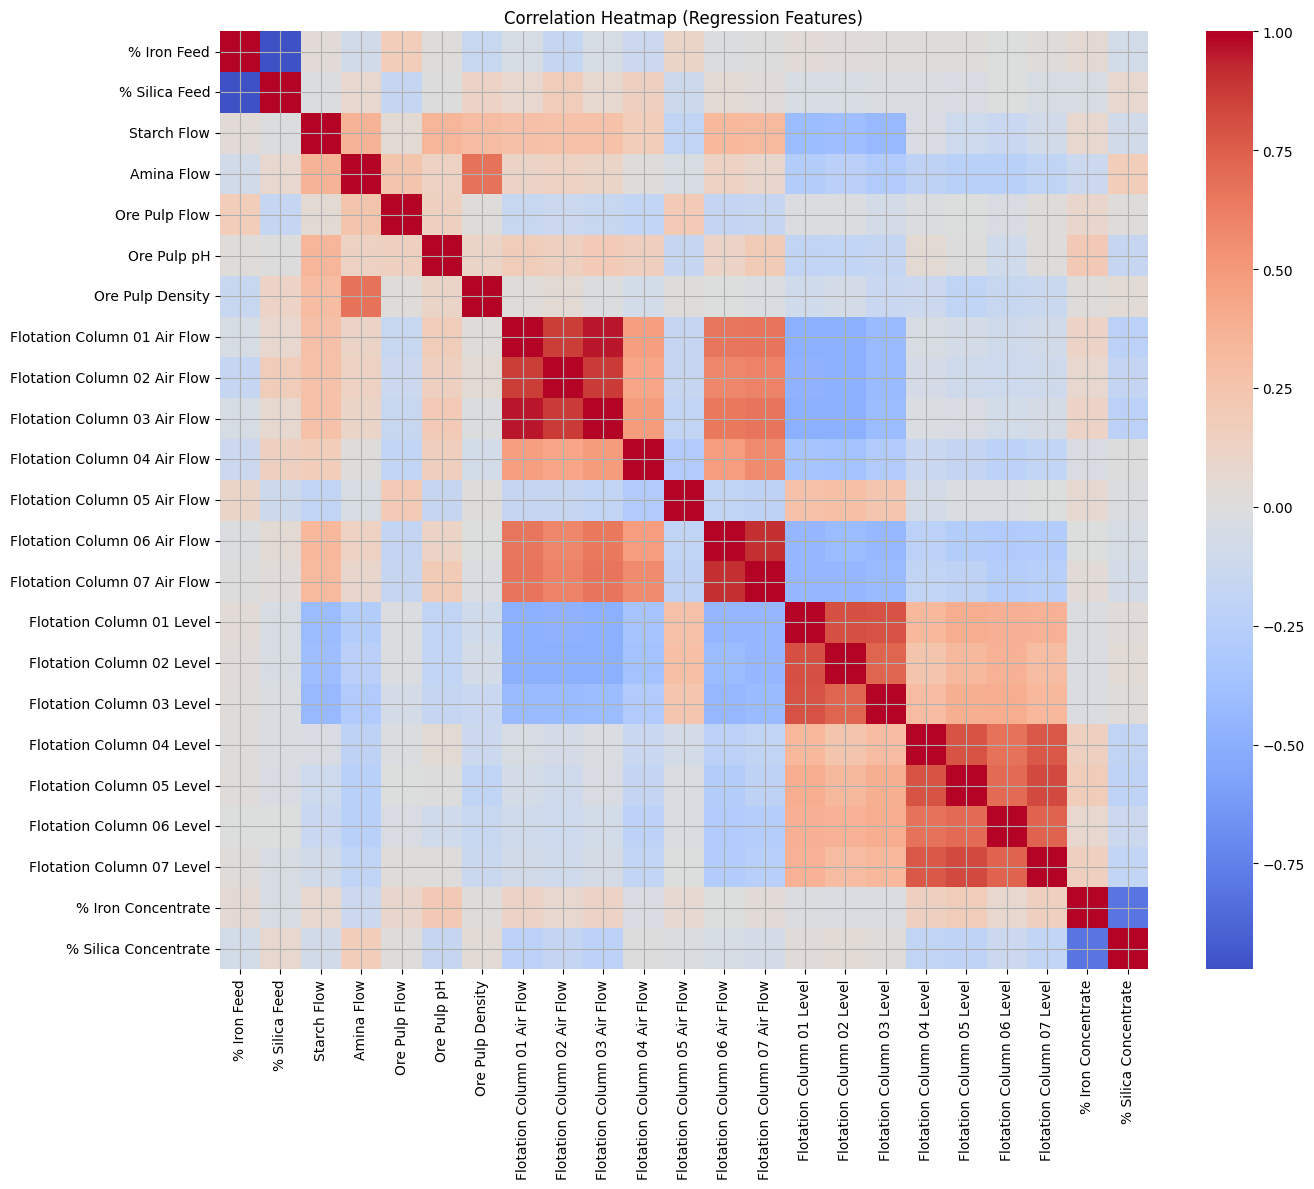

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
% Iron Feed,1.000000,-0.972047,0.030933,-0.093785,0.182895,0.014026,-0.148803,-0.049256,-0.163703,-0.048144,...,0.004621,0.033463,0.025516,0.020001,0.011398,0.016096,-0.008925,0.017287,0.054285,-0.085503
% Silica Feed,-0.972047,1.000000,-0.014637,0.081443,-0.170492,-0.000599,0.126092,0.077022,0.175415,0.068119,...,0.023315,-0.043095,-0.044265,-0.028824,-0.031673,-0.038061,-0.008252,-0.040091,-0.042923,0.082566
Starch Flow,0.030933,-0.014637,1.000000,0.365694,0.049626,0.352483,0.299222,0.280294,0.275554,0.271855,...,0.316547,-0.410414,-0.397326,-0.425630,-0.035987,-0.111110,-0.141156,-0.089381,0.076231,-0.089539
Amina Flow,-0.093785,0.081443,0.365694,1.000000,0.249450,0.131629,0.673053,0.119217,0.134992,0.108100,...,0.086112,-0.276929,-0.232592,-0.293718,-0.216308,-0.245831,-0.242658,-0.200239,-0.125858,0.180346
Ore Pulp Flow,0.182895,-0.170492,0.049626,0.249450,1.000000,0.149025,0.019878,-0.151049,-0.131317,-0.154248,...,-0.159743,-0.017065,-0.022417,-0.077078,-0.017814,-0.002605,-0.037042,0.015238,0.090560,0.012050
Ore Pulp pH,0.014026,-0.000599,0.352483,0.131629,0.149025,1.000000,0.108475,0.169244,0.152348,0.201580,...,0.191923,-0.189077,-0.180673,-0.166461,0.050258,0.004286,-0.099951,0.013752,0.207042,-0.160985
Ore Pulp Density,-0.148803,0.126092,0.299222,0.673053,0.019878,0.108475,1.000000,0.015619,0.049135,-0.013155,...,-0.031414,-0.101334,-0.073317,-0.142755,-0.131989,-0.198394,-0.153293,-0.139310,0.010359,0.040395
Flotation Column 01 Air Flow,-0.049256,0.077022,0.280294,0.119217,-0.151049,0.169244,0.015619,1.000000,0.861870,0.958320,...,0.661433,-0.490638,-0.493095,-0.423260,-0.046686,-0.072727,-0.106941,-0.092356,0.126028,-0.226252
Flotation Column 02 Air Flow,-0.163703,0.175415,0.275554,0.134992,-0.131317,0.152348,0.049135,0.861870,1.000000,0.874899,...,0.600869,-0.485804,-0.496208,-0.421688,-0.068181,-0.102050,-0.110822,-0.102041,0.082481,-0.174562
Flotation Column 03 Air Flow,-0.048144,0.068119,0.271855,0.108100,-0.154248,0.201580,-0.013155,0.958320,0.874899,1.000000,...,0.662155,-0.490942,-0.490122,-0.416977,-0.025896,-0.038339,-0.080939,-0.059165,0.129493,-0.226228


In [6]:
# [과제] 상관관계 히트맵
num_cols = reg_df.drop(columns=["date"]).select_dtypes(include="number").columns
corr_mat = reg_df[num_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_mat, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap (Regression Features)")
plt.tight_layout()
plt.show()

# 해석: |corr|가 0.8 이상인 변수 쌍은 다중공선성 후보.
# 트리 기반 앙상블(RF, GBM, XGBoost 등)은 변수 분할로 학습하므로
# 선형 모델(Ridge/Lasso)만큼 다중공선성에 민감하지 않음.
corr_mat


---
## A-2) 데이터 전처리

### A-2-1) 불필요한 변수 제거 및 결측치 확인

**[과제]** 써니는 Heatmap을 통해 타겟변수와 강한 상관관계를 가지는 변수를 발견하였습니다. 해당 변수가 데이터 누수를 유발할 수 있는지가 궁금해졌습니다. AI와 함께 상의하여 해당 변수 제거 여부를 검토하고 결정해보세요.

In [7]:
# [과제] 불필요한 변수 제거 및 결측치 확인

# 제거 대상
# - % Iron Concentrate: 타겟과 동시에 측정된 최종 정광 결과 -> 데이터 누수 후보
# - date: 시계열 정렬/분할용, 모델 입력으로는 사용하지 않음
drop_cols = ["% Iron Concentrate", "date"]

reg_model_df = reg_df.drop(columns=drop_cols)

print("[결측치 개수]")
print(reg_model_df.isna().sum())
print("\n모델링용 데이터 shape:", reg_model_df.shape)
print("타겟 변수:", "% Silica Concentrate")


[결측치 개수]
% Iron Feed                     0
% Silica Feed                   0
Starch Flow                     0
Amina Flow                      0
Ore Pulp Flow                   0
Ore Pulp pH                     0
Ore Pulp Density                0
Flotation Column 01 Air Flow    0
Flotation Column 02 Air Flow    0
Flotation Column 03 Air Flow    0
Flotation Column 04 Air Flow    0
Flotation Column 05 Air Flow    0
Flotation Column 06 Air Flow    0
Flotation Column 07 Air Flow    0
Flotation Column 01 Level       0
Flotation Column 02 Level       0
Flotation Column 03 Level       0
Flotation Column 04 Level       0
Flotation Column 05 Level       0
Flotation Column 06 Level       0
Flotation Column 07 Level       0
% Silica Concentrate            0
dtype: int64

모델링용 데이터 shape: (3948, 22)
타겟 변수: % Silica Concentrate


### A-2-2) 입출력 변수 분할 및 데이터 분할

**[과제]** 써니는 `% Silica Concentrate`를 예측하기 위해 입력변수와 타겟 변수를 분리하려고 합니다. Day 2와 마찬가지로 시계열 데이터라는 점을 고려하여 데이터를 분할해보세요.

In [8]:
# [과제] 입출력 변수 분리 + 시계열 기준 train/test 분할

# 1) 타겟(y)과 입력(X) 분리
y_reg = reg_model_df["% Silica Concentrate"]
X_reg = reg_model_df.drop(columns=["% Silica Concentrate"])

# 2) 시계열: 앞 70% train, 뒤 30% test (shuffle 금지)
split_idx = int(len(reg_model_df) * 0.7)

X_reg_train = X_reg.iloc[:split_idx]
X_reg_test = X_reg.iloc[split_idx:]
y_reg_train = y_reg.iloc[:split_idx]
y_reg_test = y_reg.iloc[split_idx:]

print("train:", X_reg_train.shape, "| test:", X_reg_test.shape)
print("train 기간:", reg_df["date"].iloc[0], "~", reg_df["date"].iloc[split_idx - 1])
print("test  기간:", reg_df["date"].iloc[split_idx], "~", reg_df["date"].iloc[-1])


train: (2763, 21) | test: (1185, 21)
train 기간: 2017-03-29 12:00:00 ~ 2017-07-22 14:00:00
test  기간: 2017-07-22 15:00:00 ~ 2017-09-09 23:00:00


### A-2-3) 스케일링 필요 여부 검토

**[과제]** 써니는 Day 2에서는 Ridge/Lasso 모델 특성 때문에 StandardScaler를 적용했었는데 Day 3에서 사용할 Random Forest·GBM·XGBoost·LightGBM·CatBoost도 스케일링이 꼭 필요한지 AI와 상의해서 판단해 보세요.

In [9]:
# [과제] 스케일링 필요 여부 검토

# 결론:
# - 트리 기반 앙상블(RF, GBM, XGBoost, LightGBM, CatBoost): 스케일링 불필요
#   -> 분할 기준(임계값)만 사용하므로 변수 크기에 민감하지 않음
# - Day 2 선형 모델(Ridge, Lasso, LinearRegression) 비교용: 스케일링 필요

# 앙상블 모델용 (원본 스케일)
X_reg_train_tree = X_reg_train.copy()
X_reg_test_tree = X_reg_test.copy()

# 선형 모델 비교용 (StandardScaler)
scaler_reg = StandardScaler()
X_reg_train_scaled = pd.DataFrame(
    scaler_reg.fit_transform(X_reg_train),
    columns=X_reg_train.columns,
    index=X_reg_train.index,
)
X_reg_test_scaled = pd.DataFrame(
    scaler_reg.transform(X_reg_test),
    columns=X_reg_test.columns,
    index=X_reg_test.index,
)

print("[앙상블] 원본 스케일 사용:", X_reg_train_tree.shape)
print("[선형 모델 비교] 스케일링 적용:", X_reg_train_scaled.shape)
print("\n스케일링 후 train 평균(0 근처):", X_reg_train_scaled.mean().round(3).head(3).tolist())


[앙상블] 원본 스케일 사용: (2763, 21)
[선형 모델 비교] 스케일링 적용: (2763, 21)

스케일링 후 train 평균(0 근처): [0.0, -0.0, 0.0]


---
## A-3) 모델 학습 및 예측

**[과제]** 써니는 Day 2에서 학습한 회귀 모델과 Day 3에서 학습한 앙상블 모델을 동일한 데이터셋에 적용하여 성능을 비교해 보고자 합니다. AI와 함께 모델 학습, 예측, 성능 평가 코드를 작성하고, 여러 모델의 결과를 한눈에 비교할 수 있는 방법을 찾아 성능을 비교 및 분석해 보세요.

[회귀 모델 종합 비교]
              Model    RMSE      R2
5               GBM  1.0571  0.1316
8          CatBoost  1.0802  0.0934
4      RandomForest  1.0842  0.0866
3      DecisionTree  1.0986  0.0622
7          LightGBM  1.0997  0.0602
2             Lasso  1.1129  0.0375
6           XGBoost  1.1685 -0.0609
1             Ridge  1.2018 -0.1224
0  LinearRegression  1.2035 -0.1255


C:\Users\Admin\AppData\Local\Temp\ipykernel_20640\189674868.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=reg_summary, x="Model", y="R2", palette="viridis")


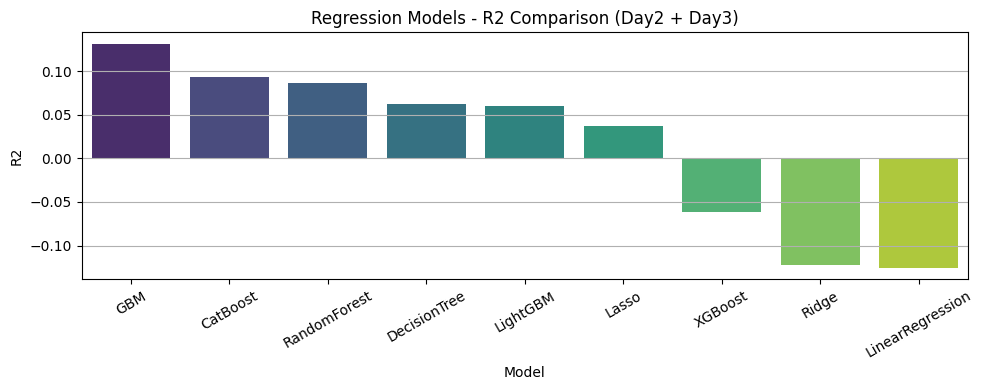

최고 성능 모델(R2 기준): GBM


In [12]:
# [과제] Day 2 + Day 3 회귀 모델 학습 및 성능 비교

def eval_reg_model(name, model, X_tr, X_te, use_scaled=False):
    if use_scaled:
        model.fit(X_reg_train_scaled, y_reg_train)
        pred = model.predict(X_reg_test_scaled)
    else:
        model.fit(X_reg_train_tree, y_reg_train)
        pred = model.predict(X_reg_test_tree)
    return {
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_reg_test, pred)),
        "R2": r2_score(y_reg_test, pred),
    }

reg_models = [
    ("LinearRegression", LinearRegression(), True),
    ("Ridge", Ridge(alpha=1.0), True),
    ("Lasso", Lasso(alpha=0.01, max_iter=10000), True),
    ("DecisionTree", DecisionTreeRegressor(random_state=0, max_depth=5), False),
    ("RandomForest", RandomForestRegressor(random_state=0, n_estimators=100), False),
    ("GBM", GradientBoostingRegressor(random_state=0), False),
    ("XGBoost", XGBRegressor(random_state=0), False),
    ("LightGBM", LGBMRegressor(random_state=0, verbose=-1), False),
    ("CatBoost", CatBoostRegressor(random_state=0, verbose=0), False),
]

reg_summary = pd.DataFrame([
    eval_reg_model(name, model, None, None, use_scaled)
    for name, model, use_scaled in reg_models
]).sort_values("R2", ascending=False)

print("[회귀 모델 종합 비교]")
print(reg_summary.round(4))

plt.figure(figsize=(10, 4))
sns.barplot(data=reg_summary, x="Model", y="R2", palette="viridis")
plt.title("Regression Models - R2 Comparison (Day2 + Day3)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

best_reg_model_name = reg_summary.iloc[0]["Model"]
print("최고 성능 모델(R2 기준):", best_reg_model_name)


---
## A-4) 모델 결과 분석 및 고도화

**[과제]** 써니는 Day 2에서 학습한 회귀 모델들과 Day 3에서 학습한 앙상블 모델들이 중요하다고 판단하는 공정 변수가 모델에 따라 얼마나 일관되게 나타나는지 궁금해졌습니다. AI와 함께 변수 중요도 및 회귀 계수를 비교할 수 있는 코드를 작성하고 여러 모델에서 공통적으로 중요하게 선정되는 핵심 공정 변수가 무엇인지 분석해 보세요.

[상위 10개 변수 - 정규화 점수]
                         feature  Ridge_abs_coef_norm  Lasso_abs_coef_norm  \
9   Flotation Column 03 Air Flow             0.786601             0.432297   
10  Flotation Column 04 Air Flow             0.798198             0.838547   
3                     Amina Flow             0.876963             0.868207   
1                  % Silica Feed             1.000000             0.199285   
7   Flotation Column 01 Air Flow             0.740027             1.000000   
20     Flotation Column 07 Level             0.057927             0.000000   
0                    % Iron Feed             0.877671             0.000000   
11  Flotation Column 05 Air Flow             0.092862             0.000000   
5                    Ore Pulp pH             0.230472             0.288375   
19     Flotation Column 06 Level             0.154388             0.001139   

    RandomForest_norm  GBM_norm  XGBoost_norm  LightGBM_norm  CatBoost_norm  
9            1.000000  1.000000      0.891

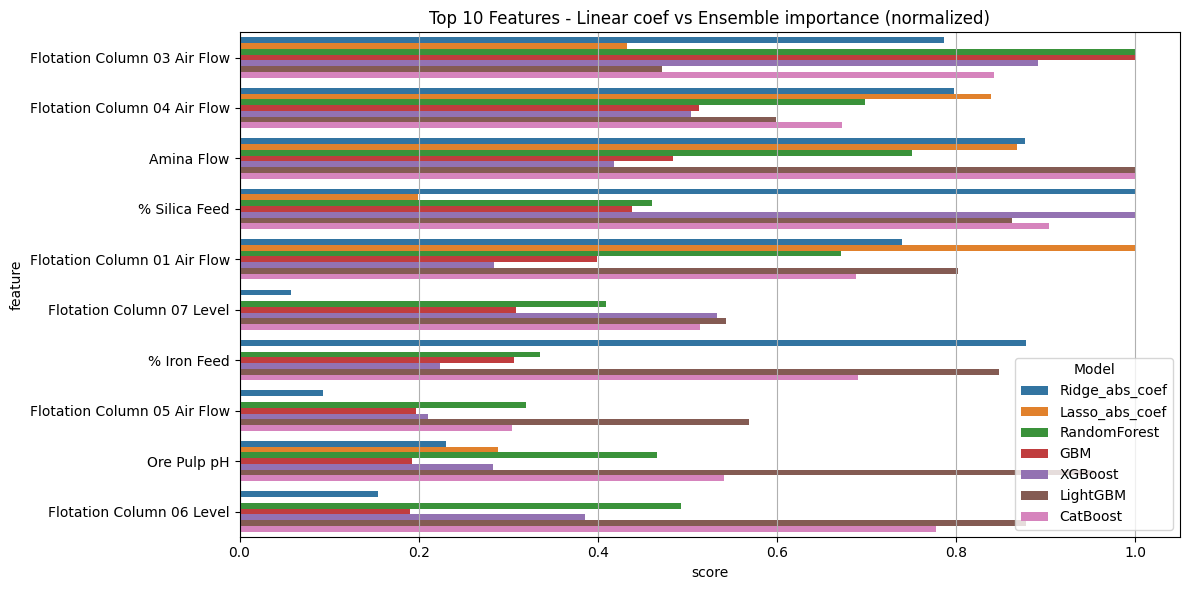

In [11]:
# [과제] 회귀 계수(coef_) vs 변수 중요도(feature_importances_) 비교

# 선형 모델 (스케일링 데이터)
ridge_imp = Ridge(alpha=1.0).fit(X_reg_train_scaled, y_reg_train)
lasso_imp = Lasso(alpha=0.01, max_iter=10000).fit(X_reg_train_scaled, y_reg_train)

# 앙상블 모델 (원본 스케일)
tree_models = {
    "RandomForest": RandomForestRegressor(random_state=0, n_estimators=100),
    "GBM": GradientBoostingRegressor(random_state=0),
    "XGBoost": XGBRegressor(random_state=0),
    "LightGBM": LGBMRegressor(random_state=0, verbose=-1),
    "CatBoost": CatBoostRegressor(random_state=0, verbose=0),
}

importance_compare = pd.DataFrame({
    "feature": X_reg_train_tree.columns,
    "Ridge_abs_coef": np.abs(ridge_imp.coef_),
    "Lasso_abs_coef": np.abs(lasso_imp.coef_),
})

for name, model in tree_models.items():
    model.fit(X_reg_train_tree, y_reg_train)
    importance_compare[name] = model.feature_importances_

# 비교를 위해 각 열을 0~1로 정규화 (스케일·의미가 달라 직접 비교 불가)
norm_cols = [c for c in importance_compare.columns if c != "feature"]
for col in norm_cols:
    max_val = importance_compare[col].max()
    importance_compare[col + "_norm"] = (
        importance_compare[col] / max_val if max_val > 0 else 0
    )

norm_cols = [c + "_norm" for c in norm_cols]
top_features = importance_compare.sort_values("GBM_norm", ascending=False).head(10)

print("[상위 10개 변수 - 정규화 점수]")
print(top_features[["feature"] + norm_cols])

plot_melt = top_features.melt(
    id_vars="feature", value_vars=norm_cols, var_name="Model", value_name="score"
)
plot_melt["Model"] = plot_melt["Model"].str.replace("_norm", "")

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_melt, x="score", y="feature", hue="Model")
plt.title("Top 10 Features - Linear coef vs Ensemble importance (normalized)")
plt.tight_layout()
plt.show()

# 해석: coef_는 방향(+/-)과 크기, importance는 분할 기여도 -> 정규화 후 순위로 비교


**[과제]** 써니는 가장 우수했던 모델의 성능을 하이퍼파라미터 튜닝으로 더 끌어올리고 싶습니다. AI와 함께 어떤 하이퍼파라미터를 어느 범위까지 탐색하면 좋을지 논의하고 GridSearchCV로 최적의 조합을 찾아 성능을 개선해 보세요.

In [ ]:
# [과제] GBM 하이퍼파라미터 튜닝 (A-3 최고 모델 기준)

# 튜닝 전 baseline
gbm_base = GradientBoostingRegressor(random_state=0)
gbm_base.fit(X_reg_train_tree, y_reg_train)
gbm_base_pred = gbm_base.predict(X_reg_test_tree)
base_r2 = r2_score(y_reg_test, gbm_base_pred)

# 시계열 CV
tscv = TimeSeriesSplit(n_splits=3)

gbm_param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "min_samples_leaf": [1, 2, 5],
}

grid_gbm = GridSearchCV(
    GradientBoostingRegressor(random_state=0),
    gbm_param_grid,
    cv=tscv,
    scoring="r2",
    n_jobs=-1,
)
grid_gbm.fit(X_reg_train_tree, y_reg_train)

best_gbm = grid_gbm.best_estimator_
best_gbm_pred = best_gbm.predict(X_reg_test_tree)
tuned_r2 = r2_score(y_reg_test, best_gbm_pred)

print("최적 파라미터:", grid_gbm.best_params_)
print("CV R2:", round(grid_gbm.best_score_, 4))
print("Test R2 (before):", round(base_r2, 4))
print("Test R2 (after):", round(tuned_r2, 4))

tuned_compare = pd.DataFrame([
    {"Model": "GBM (before)", "Test_R2": base_r2},
    {"Model": "GBM (tuned)", "Test_R2": tuned_r2},
])
print("\n[튜닝 전후 비교]")
print(tuned_compare.round(4))

# 해석: CV R2와 Test R2는 시계열에서 차이날 수 있음. 튜닝 후에도 크게 안 오를 수 있음.


---
# Part B. 분류 태스크 — Steel Plates Faults

## B-0) 데이터 불러오기

**[과제]** 써니는 Day 2에서 사용했던 `dataset/day2_miniproject_cls.csv` 파일을 그대로 불러오려고 합니다. 적절한 변수명으로 데이터프레임을 만들어 보세요.

In [ ]:
# [B-0] 분류 데이터 불러오기
cls_df = pd.read_csv(os.path.join("dataset", "day2_miniproject_cls.csv"))

print("shape:", cls_df.shape)
display(cls_df.head())
cls_df.info()


---
## B-1) 데이터 탐색 (EDA)

**[과제]** 써니는 오늘도 모델링에 앞서 데이터 상태를 다시 한번 점검하고 싶습니다. AI와 함께 데이터 구조, 결측치, 수집 기간 등 기본적인 특성을 다시 확인해 보세요.

In [ ]:
# [B-1-1] Value 기반 EDA
print("[결측치 개수]")
print(cls_df.isna().sum())

print("\n[데이터 타입]")
print(cls_df.dtypes)
print("\nshape:", cls_df.shape)

dup_cnt = cls_df.duplicated().sum()
print(f"\n[중복 행 개수] {dup_cnt}")

print("\n[K_Scatch 분포]")
print(cls_df["K_Scatch"].value_counts())
print(cls_df["K_Scatch"].value_counts(normalize=True).round(4))


**[과제]** 써니는 Day 2에서도 확인했던 타겟 변수(K_Scatch)의 클래스 불균형을 앙상블 모델링 전에 다시 한번 점검하려고 합니다. AI와 함께 타겟 변수의 빈도와 비율을 시각화해 보세요.

In [ ]:
# [B-1-2] 타겟 클래스 불균형 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

vc = cls_df["K_Scatch"].value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color=["#4daf4a", "#e41a1c"])
axes[0].set_title("K_Scatch Count")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

vp = cls_df["K_Scatch"].value_counts(normalize=True).sort_index()
axes[1].bar(vp.index.astype(str), vp.values, color=["#4daf4a", "#e41a1c"])
axes[1].set_title("K_Scatch Proportion")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# 인사이트: 클래스 0이 다수, 1이 소수 -> F1 사용, stratify 분할 필요


---
## B-2) 데이터 전처리

### B-2-1) 타겟 변수 정의

**[과제]** 써니는 K_Scatch를 분류 타겟(0/1)으로 사용하여 모델을 만들려고 합니다. 그런데 다른 결함 유형 변수들이 예측에 어떤 영향을 주는지 궁금해졌습니다. AI와 함께 각 결함 변수와 K_Scatch의 관계를 분석하고, 실제 공정 특성을 학습하기보다 정답을 미리 알려주는 역할을 하는 변수가 있는지 탐색해 보세요. 이후 이러한 변수들을 어떻게 처리하는 것이 적절할지 고민하고 적절한 전처리 방법을 적용해보세요.

In [ ]:
# [B-2-1] 결함 유형 변수 누수 검토 및 제거

fault_cols = ["Pastry", "Z_Scratch", "Stains", "Dirtiness", "Bumps", "Other_Faults"]

# 다른 결함 라벨과 K_Scatch 관계 확인
fault_target = cls_df[fault_cols + ["K_Scatch"]].corr()["K_Scatch"].drop("K_Scatch")
print("[결함 변수 vs K_Scatch 상관계수]")
print(fault_target.sort_values(ascending=False).round(4))

# 결함 유형 컬럼은 타겟과 동시에 라벨링된 정보 -> 누수 가능성, 입력에서 제거
y_cls = cls_df["K_Scatch"]
X_cls = cls_df.drop(columns=["K_Scatch"] + fault_cols)

cls_model_df = pd.concat([X_cls, y_cls], axis=1)
print("\n모델링용 shape:", cls_model_df.shape)
print("제거한 결함 라벨:", fault_cols)


### B-2-2) 결측치 확인 및 데이터 분할

**[과제]** 써니는 데이터셋에 존재하는 클래스 불균형이 모델 학습과 평가에 영향을 줄 수 있다고 생각했습니다. AI와 함께 타겟 변수의 분포를 확인하고 원본 데이터의 클래스 비율이 학습 데이터와 테스트 데이터에도 유지될 수 있도록 적절한 데이터 분할 방법을 적용해 보세요.

In [ ]:
# [B-2-2] stratify train/test 분할 (클래스 비율 유지)

X_cls_model = cls_model_df.drop(columns=["K_Scatch"])
y_cls_model = cls_model_df["K_Scatch"]

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls_model, y_cls_model,
    test_size=0.3, random_state=0, stratify=y_cls_model,
)

print("train:", X_cls_train.shape, "| test:", X_cls_test.shape)
print("\n[train 클래스 비율]")
print(y_cls_train.value_counts(normalize=True).round(4))
print("\n[test 클래스 비율]")
print(y_cls_test.value_counts(normalize=True).round(4))


### B-2-3) 스케일링/인코딩 필요 여부 검토

**[과제]** 써니는 Day 2에서 로지스틱 회귀 모델 학습을 위해 스케일링을 적용했었습니다. 이번에 사용할 앙상블 모델들도 동일한 전처리가 필요한지 궁금해졌습니다. AI와 함께 모델별 특성을 살펴보고 스케일링과 인코딩이 필요한지 판단하여 적절한 전처리를 적용해 보세요.

In [ ]:
# [B-2-3] 스케일링 필요 여부 검토

# 앙상블: 스케일링 불필요 / 로지스틱 비교용: 스케일링 필요
X_cls_train_tree = X_cls_train.copy()
X_cls_test_tree = X_cls_test.copy()

scaler_cls = StandardScaler()
X_cls_train_scaled = pd.DataFrame(
    scaler_cls.fit_transform(X_cls_train),
    columns=X_cls_train.columns,
    index=X_cls_train.index,
)
X_cls_test_scaled = pd.DataFrame(
    scaler_cls.transform(X_cls_test),
    columns=X_cls_test.columns,
    index=X_cls_test.index,
)

print("[앙상블] 원본 스케일:", X_cls_train_tree.shape)
print("[로지스틱 비교] 스케일링 적용:", X_cls_train_scaled.shape)


---
## B-3) 모델 학습 및 예측

**[과제]** 써니는 Day 2에서 학습한 회귀 모델과 Day 3에서 학습한 앙상블 모델을 동일한 데이터셋에 적용하여 성능을 비교해 보고자 합니다. AI와 함께 모델 학습, 예측, 성능 평가 코드를 작성하고, 여러 모델의 결과를 한눈에 비교할 수 있는 방법을 찾아 성능을 비교 및 분석해 보세요.

In [ ]:
# [B-3] Day2 + Day3 분류 모델 학습 및 F1 비교

def eval_cls_model(name, model, use_scaled=False):
    if use_scaled:
        model.fit(X_cls_train_scaled, y_cls_train)
        pred = model.predict(X_cls_test_scaled)
    else:
        model.fit(X_cls_train_tree, y_cls_train)
        pred = model.predict(X_cls_test_tree)
    return {
        "Model": name,
        "F1": f1_score(y_cls_test, pred),
        "Accuracy": accuracy_score(y_cls_test, pred),
    }

cls_models = [
    ("LogisticRegression", LogisticRegression(max_iter=1000), True),
    ("DecisionTree", DecisionTreeClassifier(random_state=0, max_depth=5), False),
    ("RandomForest", RandomForestClassifier(random_state=0, n_estimators=100), False),
    ("GBM", GradientBoostingClassifier(random_state=0), False),
    ("XGBoost", XGBClassifier(random_state=0, eval_metric="logloss"), False),
    ("LightGBM", LGBMClassifier(random_state=0, verbose=-1), False),
    ("CatBoost", CatBoostClassifier(random_state=0, verbose=0), False),
]

cls_summary = pd.DataFrame([
    eval_cls_model(name, model, use_scaled)
    for name, model, use_scaled in cls_models
]).sort_values("F1", ascending=False)

print("[분류 모델 종합 비교]")
print(cls_summary.round(4))

plt.figure(figsize=(10, 4))
sns.barplot(data=cls_summary, x="Model", y="F1", palette="magma")
plt.title("Classification Models - F1 Comparison (Day2 + Day3)")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

best_cls_model_name = cls_summary.iloc[0]["Model"]
print("최고 성능 모델(F1 기준):", best_cls_model_name)


---
## B-5) 모델 결과 분석 및 고도화

**[과제]** 써니는 클래스 불균형이 성능에 영향을 줄 수 있다고 생각했습니다. 다만 모델마다 불균형을 다루는 방식이 다르다는 것을 알게 되었습니다. AI와 함께 각 모델에 맞는 불균형 완화 방법을 적용하고 적용 전후 성능을 비교해 보세요.

> 예:Random Forest는 `class_weight`, GBM은 `sample_weight`, XGBoost는 `scale_pos_weight`, LightGBM은 `is_unbalance`, CatBoost는 `auto_class_weights`

In [ ]:
# [B-4-1] 불균형 완화 전후 성능 비교

pos_weight = (y_cls_train == 0).sum() / (y_cls_train == 1).sum()

imbalance_models = {
    "RF (default)": RandomForestClassifier(random_state=0, n_estimators=100),
    "RF (balanced)": RandomForestClassifier(random_state=0, n_estimators=100, class_weight="balanced"),
    "GBM (default)": GradientBoostingClassifier(random_state=0),
    "XGB (default)": XGBClassifier(random_state=0, eval_metric="logloss"),
    "XGB (scale_pos_weight)": XGBClassifier(
        random_state=0, eval_metric="logloss", scale_pos_weight=pos_weight
    ),
    "LGBM (default)": LGBMClassifier(random_state=0, verbose=-1),
    "LGBM (balanced)": LGBMClassifier(random_state=0, verbose=-1, class_weight="balanced"),
    "CatBoost (default)": CatBoostClassifier(random_state=0, verbose=0),
    "CatBoost (auto_balanced)": CatBoostClassifier(random_state=0, verbose=0, auto_class_weights="Balanced"),
}

imb_results = []
for name, model in imbalance_models.items():
    model.fit(X_cls_train_tree, y_cls_train)
    pred = model.predict(X_cls_test_tree)
    imb_results.append({
        "Model": name,
        "F1": f1_score(y_cls_test, pred),
        "Recall": recall_score(y_cls_test, pred),
        "Precision": precision_score(y_cls_test, pred),
    })

imb_df = pd.DataFrame(imb_results).sort_values("F1", ascending=False)
print("[불균형 완화 전후 비교]")
print(imb_df.round(4))

plt.figure(figsize=(12, 4))
sns.barplot(data=imb_df, x="Model", y="F1")
plt.title("Imbalance Handling - F1 Comparison")
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()


**[과제]** 써니는 불균형 완화까지 적용한 5개 모델의 변수 중요도를 비교해서, K_Scatch 결함 여부에 공통적으로 큰 영향을 주는 변수가 무엇인지 확인하려고 합니다. AI와 상의해서 비교 시각화를 만들어 보세요.

In [ ]:
# [B-4-2] 5개 앙상블 변수 중요도 비교 (불균형 완화 적용)

ensemble_imb = {
    "RandomForest": RandomForestClassifier(random_state=0, n_estimators=100, class_weight="balanced"),
    "GBM": GradientBoostingClassifier(random_state=0),
    "XGBoost": XGBClassifier(random_state=0, eval_metric="logloss", scale_pos_weight=pos_weight),
    "LightGBM": LGBMClassifier(random_state=0, verbose=-1, class_weight="balanced"),
    "CatBoost": CatBoostClassifier(random_state=0, verbose=0, auto_class_weights="Balanced"),
}

cls_imp_dict = {}
for name, model in ensemble_imb.items():
    model.fit(X_cls_train_tree, y_cls_train)
    cls_imp_dict[name] = pd.Series(
        model.feature_importances_, index=X_cls_train_tree.columns
    ).sort_values(ascending=False)

cls_imp_df = pd.DataFrame(cls_imp_dict)
k_cls = 10
top_cls_vars = cls_imp_df.max(axis=1).sort_values(ascending=False).head(k_cls).index
cls_imp_topk = cls_imp_df.loc[top_cls_vars]

plot_cls = cls_imp_topk.reset_index().melt(
    id_vars="index", var_name="Model", value_name="Importance"
).rename(columns={"index": "Variable"})

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_cls, x="Importance", y="Variable", hue="Model", orient="h")
plt.title("Top 10 Feature Importance - 5 Ensemble Models (Classification)")
plt.tight_layout()
plt.show()

print("[Spearman 순위 일치도]")
print(cls_imp_df.corr(method="spearman").round(3))


**[과제]** 써니는 불균형 완화 이후 F1-score가 가장 좋았던 모델의 성능을 하이퍼파라미터 튜닝으로 더 끌어올리고 싶습니다. AI와 함께 적절한 탐색 범위를 설정하여 GridSearchCV로 성능을 개선해 보세요.

In [ ]:
# [B-4-3] 최고 F1 모델 하이퍼파라미터 튜닝 (XGBoost 기준)

xgb_base = XGBClassifier(random_state=0, eval_metric="logloss", scale_pos_weight=pos_weight)
xgb_base.fit(X_cls_train_tree, y_cls_train)
base_pred = xgb_base.predict(X_cls_test_tree)
base_f1 = f1_score(y_cls_test, base_pred)

xgb_param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
}

grid_xgb_cls = GridSearchCV(
    XGBClassifier(random_state=0, eval_metric="logloss", scale_pos_weight=pos_weight),
    xgb_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)
grid_xgb_cls.fit(X_cls_train_tree, y_cls_train)

best_xgb_cls = grid_xgb_cls.best_estimator_
tuned_pred = best_xgb_cls.predict(X_cls_test_tree)
tuned_f1 = f1_score(y_cls_test, tuned_pred)

print("최적 파라미터:", grid_xgb_cls.best_params_)
print("CV F1:", round(grid_xgb_cls.best_score_, 4))
print("Test F1 (before):", round(base_f1, 4))
print("Test F1 (after):", round(tuned_f1, 4))

pd.DataFrame([
    {"Model": "XGBoost (before)", "F1": base_f1},
    {"Model": "XGBoost (tuned)", "F1": tuned_f1},
]).round(4)
